# Partial RSA and Variance Partitioning

This notebook extends the EEG-fMRI RSA pipeline with two analyses:

1. **Pairwise partial Spearman correlations** between each model RDM (VA, CLIP-ViT, GIST) and the fMRI RDM, controlling for the other models.
2. **Variance partitioning** via nested OLS regression, giving unique, pairwise-shared, and fully-shared variance components.

Both are applied to the **fMRI ROI where VA-defined and CLIP-ViT-defined searchlight results overlap**, and then extended to time-resolved EEG RDMs.

The key interpretive claims are:
- `unique_VA > 0` in the overlap ROI means valence-arousal carries affective structure **not reducible** to scene semantics.
- Large `shared_VA_CLIP_only` means the two models converge on a common representational axis — the convergence-zone signature.
- In the temporal (EEG) version, comparing the peak latencies of `unique_VA` vs `unique_CLIP` tells you whether emotion and scene semantic codes emerge at different times.

In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr, ttest_1samp, zscore, rankdata
from tqdm import tqdm

## 1. Helper functions

In [2]:
def upper_tri(RDM):
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

def rdm_from_features(features, metric='euclidean'):
    return pairwise_distances(features, metric=metric)

def smooth(data, window_size=50):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

## 2. Load data

Assumes the same inputs as the main pipeline plus three model-feature files. Adjust the paths.

In [4]:
# Paths (edit these)
PATH_ALLSUB       = "../IAPS_Searchlight/allsub_avg.npy"
PATH_EEG          = "../IAPS_EEG_RSA/eeg_raw.npy"
PATH_VA_MASK      = "../IAPS_Searchlight/outputs/tBrainmap/final_results/tmap_beh60_p05_v2.nii.gz"
PATH_CLIP_MASK    = "../IAPS_Searchlight/outputs/tBrainmap/final_results/tmap_clipvit_p001_fisherz_fdr01.nii.gz"
PATH_IAPS_RATINGS = "iaps_ratings.csv"       # columns: valence, arousal
PATH_CLIP_FEATURES= "clipvit_features.npy"   # (60, D)
PATH_GIST_FEATURES= "gist_features.npy"      # (60, D)
OUT_DIR           = "./partial_rsa_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# fMRI and EEG
allsub = np.load(PATH_ALLSUB, allow_pickle=True)       # (20, 60, X, Y, Z)
eeg    = np.load(PATH_EEG)                              # (20, 31, 60, 575)
print("allsub shape:", allsub.shape)
print("eeg shape   :", eeg.shape)

# Masks
va_mask_img   = nib.load(PATH_VA_MASK)
clip_mask_img = nib.load(PATH_CLIP_MASK)
va_mask   = va_mask_img.get_fdata() > 0
clip_mask = clip_mask_img.get_fdata() > 0
print("VA mask voxels  :", int(va_mask.sum()))
print("CLIP mask voxels:", int(clip_mask.sum()))

overlap_mask = va_mask & clip_mask
print("Overlap voxels  :", int(overlap_mask.sum()))

# Reshape brain data
brain_data = allsub.reshape(allsub.shape[0], 60, *va_mask.shape)

allsub shape: (20, 60, 153594)
eeg shape   : (20, 31, 60, 575)
VA mask voxels  : 1038
CLIP mask voxels: 2027
Overlap voxels  : 484


## 3. Build model RDMs

Valence–arousal uses the normative IAPS ratings; CLIP-ViT and GIST use the feature vectors you already have from the main pipeline. All three use Euclidean distance, matching the main pipeline's convention.

In [7]:
# Load pre-computed RDMs
rdm_clipvit = pd.read_csv(r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\RDM\rdm_clipvit.csv")
clip_rdm = np.array(rdm_clipvit)

rdm_beh = pd.read_csv(r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\RDM\rdm_behavioral.csv", index_col=0)
rdm_beh = np.array(rdm_beh)
va_rdm = (rdm_beh - np.min(rdm_beh)) / (np.max(rdm_beh) - np.min(rdm_beh))  # min-max normalize

rdm_gist = pd.read_csv(r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\RDM\rdm_gist.csv", index_col=0)
gist_rdm = np.array(rdm_gist)

# Sanity-check shapes (should all be 60 x 60)
print("VA RDM shape  :", va_rdm.shape)
print("CLIP RDM shape:", clip_rdm.shape)
print("GIST RDM shape:", gist_rdm.shape)

model_rdms = {'VA': va_rdm, 'CLIP': clip_rdm, 'GIST': gist_rdm}

# Inter-model correlations — high correlations = shaky partitioning
print("\nModel RDM inter-correlations (Spearman):")
names = list(model_rdms.keys())
for i, a in enumerate(names):
    for b in names[i+1:]:
        r, _ = spearmanr(upper_tri(model_rdms[a]), upper_tri(model_rdms[b]))
        print(f"  {a} vs {b}: r = {r:.3f}")

VA RDM shape  : (60, 60)
CLIP RDM shape: (60, 60)
GIST RDM shape: (60, 60)

Model RDM inter-correlations (Spearman):
  VA vs CLIP: r = 0.290
  VA vs GIST: r = -0.027
  CLIP vs GIST: r = 0.081


**Interpretive note:** If any two model RDMs correlate above ~0.85, the variance partitioning becomes unstable because the predictors are nearly collinear. In that case, report the pairwise partial correlations and be cautious about over-interpreting small unique components.

## 4. Extract fMRI RDMs from the overlap ROI

In [8]:
def compute_rdm_in_mask(brain_data, mask):
    n_subj, n_stim = brain_data.shape[:2]
    flat = mask.ravel()
    X = brain_data.reshape(n_subj, n_stim, -1)
    rdms = np.zeros((n_subj, n_stim, n_stim))
    for s in range(n_subj):
        Xs = np.nan_to_num(X[s][:, flat])
        rdms[s] = pairwise_distances(Xs, metric='correlation')
    return rdms

overlap_rdms = compute_rdm_in_mask(brain_data, overlap_mask)
print("Overlap ROI fMRI RDMs shape:", overlap_rdms.shape)

Overlap ROI fMRI RDMs shape: (20, 60, 60)


## 5. Pairwise partial Spearman correlations

For each subject, partial out the other two models and check whether the target model still explains the fMRI RDM in the overlap ROI.

In [9]:
def partial_spearman(y, x, covariates):
    yr = rankdata(y)
    xr = rankdata(x)
    Cr = np.column_stack([rankdata(covariates[:, j]) for j in range(covariates.shape[1])])
    design = np.column_stack([np.ones(len(yr)), Cr])
    b_y, *_ = np.linalg.lstsq(design, yr, rcond=None)
    b_x, *_ = np.linalg.lstsq(design, xr, rcond=None)
    y_res = yr - design @ b_y
    x_res = xr - design @ b_x
    r, _ = pearsonr(y_res, x_res)
    return r

def pairwise_partial_rsa(fmri_rdms, model_rdms):
    names = list(model_rdms.keys())
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    n_subj = fmri_rdms.shape[0]
    zero_order = {m: np.zeros(n_subj) for m in names}
    partial    = {m: np.zeros(n_subj) for m in names}
    for s in range(n_subj):
        yv = upper_tri(fmri_rdms[s])
        for m in names:
            covs = np.column_stack([mv[k] for k in names if k != m])
            partial[m][s] = partial_spearman(yv, mv[m], covs)
            r, _ = spearmanr(yv, mv[m])
            zero_order[m][s] = r
    df_z = pd.DataFrame(zero_order); df_z.columns = [f"{m}_zeroorder" for m in names]
    df_p = pd.DataFrame(partial);    df_p.columns = [f"{m}_partial"   for m in names]
    return pd.concat([df_z, df_p], axis=1)

df_partial = pairwise_partial_rsa(overlap_rdms, model_rdms)
df_partial.describe().loc[['mean', 'std']]

,VA_zeroorder,CLIP_zeroorder,GIST_zeroorder,VA_partial,CLIP_partial,GIST_partial
mean,0.114907,0.176922,0.050924,0.069952,0.147562,0.041063
std,0.070821,0.078700,0.063079,0.071813,0.079752,0.063146


In [10]:
# Group-level one-sample t-tests (one-sided: is the partial correlation > 0?)
def group_stats(df, cols):
    rows = []
    for c in cols:
        vals = df[c].values
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        rows.append({'component': c, 'mean': vals.mean(),
                     'sem': vals.std(ddof=1)/np.sqrt(len(vals)),
                     't': t, 'p_one_sided': p})
    return pd.DataFrame(rows)

stats_partial = group_stats(df_partial, df_partial.columns.tolist())
print(stats_partial.to_string(index=False))
stats_partial.to_csv(os.path.join(OUT_DIR, 'fmri_partial_rsa_stats.csv'), index=False)
df_partial.to_csv(os.path.join(OUT_DIR, 'fmri_partial_rsa_per_subject.csv'))

     component     mean      sem         t  p_one_sided
  VA_zeroorder 0.114907 0.015836  7.256077 3.460219e-07
CLIP_zeroorder 0.176922 0.017598 10.053680 2.413916e-09
GIST_zeroorder 0.050924 0.014105  3.610367 9.319772e-04
    VA_partial 0.069952 0.016058  4.356236 1.699677e-04
  CLIP_partial 0.147562 0.017833  8.274652 5.057403e-08
  GIST_partial 0.041063 0.014120  2.908175 4.507613e-03


**What to look for:** `VA_partial` significantly > 0 means the affective geometry in the overlap ROI is not fully reducible to CLIP-ViT scene semantics. If `VA_partial` drops to ~0 but `VA_zeroorder` is large, the VA effect is largely explained by scene semantics (the deflationary reading). Either result is publishable; the interpretation differs.

## 6. Variance partitioning (commonality analysis)

Decompose R² into 7 components: three unique (one per model), three pairwise-shared-only, and one shared-by-all-three.

In [11]:
def _r2(X, y):
    if X.ndim == 1: X = X.reshape(-1, 1)
    X = np.nan_to_num(zscore(X, axis=0, ddof=1))
    yz = zscore(y, ddof=1)
    m = LinearRegression().fit(X, yz)
    return m.score(X, yz)

def variance_partition(y, predictors):
    assert len(predictors) == 3
    (n1, x1), (n2, x2), (n3, x3) = list(predictors.items())

    r1 = _r2(x1, y); r2 = _r2(x2, y); r3 = _r2(x3, y)
    r12 = _r2(np.column_stack([x1, x2]), y)
    r13 = _r2(np.column_stack([x1, x3]), y)
    r23 = _r2(np.column_stack([x2, x3]), y)
    rall = _r2(np.column_stack([x1, x2, x3]), y)

    u1 = rall - r23
    u2 = rall - r13
    u3 = rall - r12
    c12 = r1 + r2 - r12
    c13 = r1 + r3 - r13
    c23 = r2 + r3 - r23
    c123 = r1 + r2 + r3 - r12 - r13 - r23 + rall
    s12_only = c12 - c123
    s13_only = c13 - c123
    s23_only = c23 - c123

    return {
        'R2_full': rall,
        f'unique_{n1}': u1, f'unique_{n2}': u2, f'unique_{n3}': u3,
        f'shared_{n1}_{n2}_only': s12_only,
        f'shared_{n1}_{n3}_only': s13_only,
        f'shared_{n2}_{n3}_only': s23_only,
        'shared_all': c123,
    }

def variance_partition_per_subject(fmri_rdms, model_rdms):
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    rows = []
    for s in range(fmri_rdms.shape[0]):
        yv = upper_tri(fmri_rdms[s])
        row = variance_partition(yv, mv); row['subject'] = s
        rows.append(row)
    return pd.DataFrame(rows).set_index('subject')

df_vp = variance_partition_per_subject(overlap_rdms, model_rdms)
df_vp.head()

,R2_full,unique_VA,unique_CLIP,unique_GIST,shared_VA_CLIP_only,shared_VA_GIST_only,shared_CLIP_GIST_only,shared_all
subject,,,,,,,,
0,0.054231,0.002373,0.034439,0.004644,0.010023,-0.000368,0.003267,-0.000147
1,0.030400,0.004505,0.008008,0.010792,0.005406,-0.000771,0.002282,0.000179
2,0.025342,0.002221,0.015921,0.000561,0.005955,-0.000122,0.000860,-0.000053
3,0.033316,0.010861,0.011789,0.000252,0.010087,-0.000157,0.000527,-0.000043
4,0.088822,0.043666,0.013639,0.009905,0.022643,0.002645,-0.002285,-0.001392


In [12]:
vp_cols = [c for c in df_vp.columns if c.startswith(('unique_', 'shared_', 'R2_full'))]
stats_vp = group_stats(df_vp, vp_cols)
print(stats_vp.to_string(index=False))
stats_vp.to_csv(os.path.join(OUT_DIR, 'fmri_variance_partition_stats.csv'), index=False)
df_vp.to_csv(os.path.join(OUT_DIR, 'fmri_variance_partition_per_subject.csv'))

            component      mean      sem         t  p_one_sided
              R2_full  0.048055 0.005788  8.303281 4.800802e-08
            unique_VA  0.006776 0.002460  2.753872 6.314240e-03
          unique_CLIP  0.023941 0.004013  5.965858 4.827431e-06
          unique_GIST  0.008677 0.002169  4.000545 3.826194e-04
  shared_VA_CLIP_only  0.006785 0.001807  3.754100 6.716769e-04
  shared_VA_GIST_only -0.000017 0.000175 -0.099654 5.391686e-01
shared_CLIP_GIST_only  0.002106 0.000611  3.445687 1.354635e-03
           shared_all -0.000212 0.000078 -2.700019 9.929057e-01


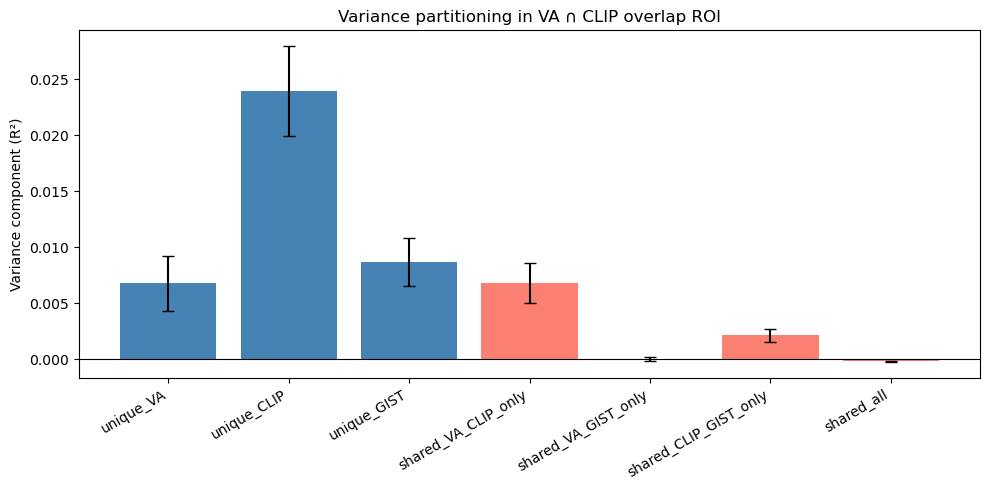

In [13]:
# Bar plot of variance components
components = [c for c in df_vp.columns if c.startswith(('unique_', 'shared_'))]
means = df_vp[components].mean()
sems  = df_vp[components].sem()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if 'unique' in c else 'salmon' for c in components]
ax.bar(range(len(means)), means, yerr=sems, capsize=4, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(means)))
ax.set_xticklabels(components, rotation=30, ha='right')
ax.set_ylabel("Variance component (R²)")
ax.set_title("Variance partitioning in VA ∩ CLIP overlap ROI")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fmri_variance_partition.png'), dpi=150)
plt.show()

**How to read this:** Blue bars (unique components) answer 'does this model explain variance no other model explains?' Salmon bars (shared components) answer 'how much do models jointly explain?' The `shared_VA_CLIP_only` bar is your quantitative estimate of the convergence-zone overlap — affective structure that co-exists with scene semantics in this ROI.

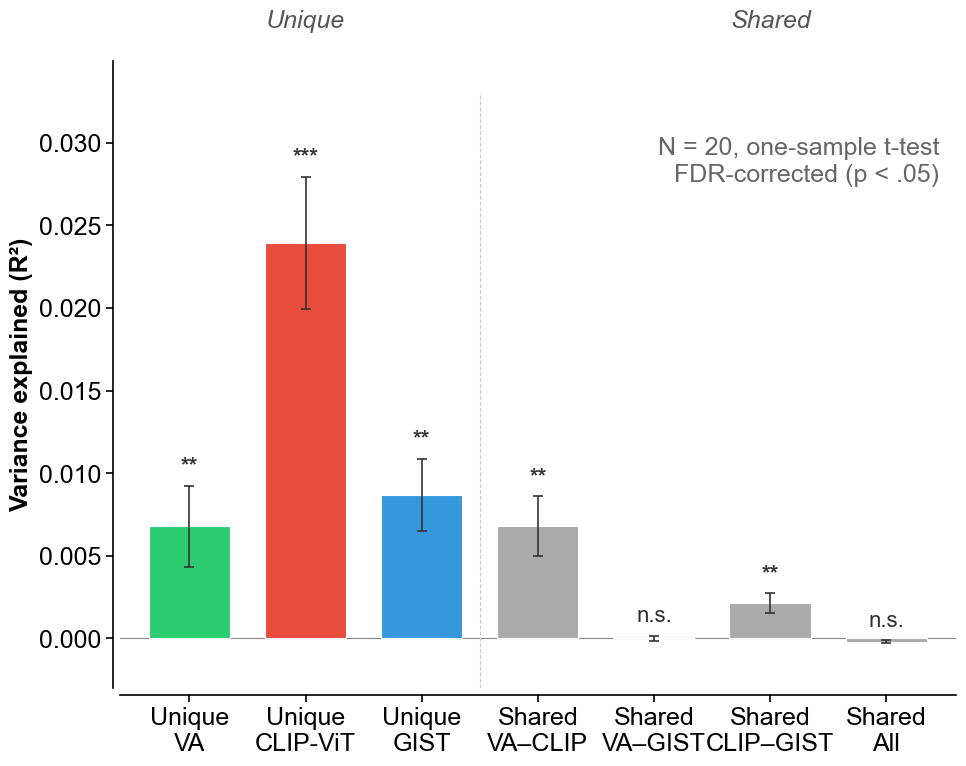


Component                     Mean      SEM        t     p(FDR)   Sig
----------------------------------------------------------------------
unique_VA                   0.0068   0.0025     2.75     0.0088    **
unique_CLIP                 0.0239   0.0040     5.97     0.0000   ***
unique_GIST                 0.0087   0.0022     4.00     0.0013    **
shared_VA_CLIP_only         0.0068   0.0018     3.75     0.0016    **
shared_VA_GIST_only        -0.0000   0.0002    -0.10     0.6290  n.s.
shared_CLIP_GIST_only       0.0021   0.0006     3.45     0.0024    **
shared_all                 -0.0002   0.0001    -2.70     0.9929  n.s.


In [44]:
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_1samp
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ---- Stats ----
components = ['unique_VA', 'unique_CLIP', 'unique_GIST',
              'shared_VA_CLIP_only', 'shared_VA_GIST_only',
              'shared_CLIP_GIST_only', 'shared_all']

display_labels = [
    'Unique\nVA',
    'Unique\nCLIP-ViT',
    'Unique\nGIST',
    'Shared\nVA–CLIP',
    'Shared\nVA–GIST',
    'Shared\nCLIP–GIST',
    'Shared\nAll'
]

n_subj = len(df_vp)
means = df_vp[components].mean().values
sems = df_vp[components].sem().values

p_uncorr = []
t_vals = []
for c in components:
    t, p = ttest_1samp(df_vp[c].values, 0.0, alternative='greater')
    p_uncorr.append(p)
    t_vals.append(t)
p_uncorr = np.array(p_uncorr)

rejected, p_fdr = fdrcorrection(p_uncorr, alpha=0.05)

def p_to_stars(p):
    if p < 0.001:   return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return 'n.s.'

# ---- Plot config ----
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 18,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

shared_color = '#AAAAAA'
point_color = '#2C2C2C'

color_map = {
    'unique_VA':              '#2ecc71',   # green (Emotion)
    'unique_CLIP':            '#e74c3c',   # red (Scene)
    'unique_GIST':            '#3498db',   # blue (GIST)
    'shared_VA_CLIP_only':    shared_color,
    'shared_VA_GIST_only':    shared_color,
    'shared_CLIP_GIST_only':  shared_color,
    'shared_all':             shared_color,
}

bar_colors = [color_map[c] for c in components]

# ---- Figure ----
fig, ax = plt.subplots(figsize=(10, 8))

x = np.arange(len(components))
bar_width = 0.70

bars = ax.bar(x, means, width=bar_width, color=bar_colors,
              edgecolor='white', linewidth=0.8, zorder=2)

ax.errorbar(x, means, yerr=sems, fmt='none', ecolor='#333333',
            elinewidth=1.2, capsize=3.5, capthick=1.2, zorder=3)

# # Individual subject data points
# np.random.seed(42)
# for i, c in enumerate(components):
#     subj_vals = df_vp[c].values
#     jitter = np.random.uniform(-0.15, 0.15, size=n_subj)
#     ax.scatter(x[i] + jitter, subj_vals, s=14, color=point_color,
#                alpha=0.35, edgecolors='none', zorder=4)

# Significance stars
for i, p in enumerate(p_fdr):
    star = p_to_stars(p)
    y_pos = means[i] + sems[i] + 0.0006
    fontweight = 'bold' if star != 'n.s.' else 'normal'
    fontsize = 16 if star != 'n.s.' else 16
    ax.text(x[i], y_pos, star, ha='center', va='bottom',
            fontsize=fontsize, fontweight=fontweight, color='#333333')

ax.axhline(0, color='#888888', linewidth=0.8, linestyle='-', zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=3, linespacing=1.1)
ax.set_ylabel('Variance explained (R²)', fontsize=18, fontweight='bold')
ax.set_xlim(-0.6, len(components) - 0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))

y_max = max(means + sems) * 1.25
ax.set_ylim([-0.003, y_max])
ax.yaxis.set_major_locator(plt.MultipleLocator(0.005))

# Separator between unique and shared
ax.axvline(2.5, color='#CCCCCC', linewidth=0.8, linestyle='--', ymin=0, ymax=0.95, zorder=1)

# Group labels — above the bars
ax.text(1.0, y_max * 1.05, 'Unique', ha='center', va='bottom',
        fontsize=18, fontstyle='italic', color='#555555')
ax.text(5.0, y_max * 1.05, 'Shared', ha='center', va='bottom',
        fontsize=18, fontstyle='italic', color='#555555')

# Annotation — lower right corner
ax.text(0.98, 0.88,
        f'N = {n_subj}, one-sample t-test\nFDR-corrected (p < .05)',
        transform=ax.transAxes, fontsize=18, ha='right', va='top',
        color='#666666')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_variance_partition.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'fig_variance_partition.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print stats table
print(f"\n{'Component':<25} {'Mean':>8} {'SEM':>8} {'t':>8} {'p(FDR)':>10} {'Sig':>5}")
print('-' * 70)
for i, c in enumerate(components):
    print(f"{c:<25} {means[i]:>8.4f} {sems[i]:>8.4f} {t_vals[i]:>8.2f} {p_fdr[i]:>10.4f} {p_to_stars(p_fdr[i]):>5}")

VA-only voxels   : 554
Overlap voxels   : 484
CLIP-only voxels : 1543
Overlap RDMs shape  : (20, 60, 60)
VA-only RDMs shape  : (20, 60, 60)
CLIP-only RDMs shape: (20, 60, 60)

  VA-only ROI
      VA_zeroorder  CLIP_zeroorder  VA_partial  CLIP_partial
mean        0.0727          0.2140      0.0113        0.2025
std         0.0609          0.0587      0.0634        0.0597

  Overlap ROI
      VA_zeroorder  CLIP_zeroorder  VA_partial  CLIP_partial
mean        0.1149          0.1769      0.0677        0.1514
std         0.0708          0.0787      0.0728        0.0802

  CLIP-only ROI
      VA_zeroorder  CLIP_zeroorder  VA_partial  CLIP_partial
mean       -0.0068          0.1674     -0.0590        0.1772
std         0.0541          0.0530      0.0598        0.0578

  Group statistics (FDR-corrected across all ROIs and components)
      ROI      component      mean      sem         t     p_uncorr        p_fdr  sig
  VA-only   VA_zeroorder  0.072727 0.013609  5.344110 1.853868e-05 2.780803e-

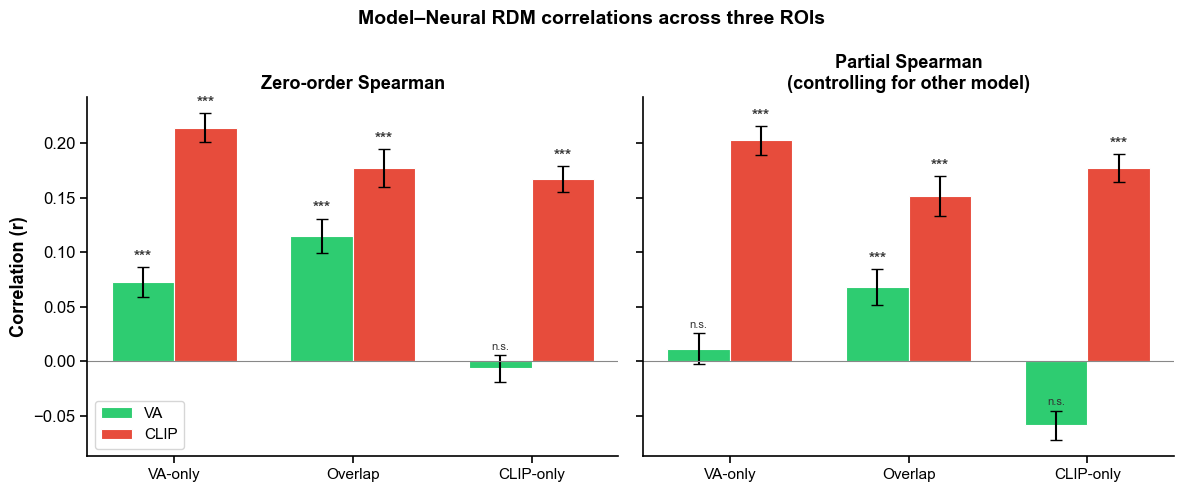


  Summary

VA-only:
  VA partial   : mean r = 0.0113, t = 0.80, p(FDR) = 0.2605 n.s.
  CLIP partial : mean r = 0.2025, t = 15.17, p(FDR) = 0.0000 ***

Overlap:
  VA partial   : mean r = 0.0677, t = 4.16, p(FDR) = 0.0004 ***
  CLIP partial : mean r = 0.1514, t = 8.44, p(FDR) = 0.0000 ***

CLIP-only:
  VA partial   : mean r = -0.0590, t = -4.41, p(FDR) = 0.9999 n.s.
  CLIP partial : mean r = 0.1772, t = 13.72, p(FDR) = 0.0000 ***


In [45]:
 # ---------------------------------------------------------------------------
# 1. Define the three ROI masks
# ---------------------------------------------------------------------------
overlap_mask = va_mask & clip_mask                    # VA ∩ CLIP
va_only_mask = va_mask & ~clip_mask                   # VA minus overlap
clip_only_mask = clip_mask & ~va_mask                 # CLIP minus overlap

print(f"VA-only voxels   : {int(va_only_mask.sum())}")
print(f"Overlap voxels   : {int(overlap_mask.sum())}")
print(f"CLIP-only voxels : {int(clip_only_mask.sum())}")

# ---------------------------------------------------------------------------
# 2. Compute fMRI RDMs for each ROI
# ---------------------------------------------------------------------------
def compute_rdm_in_mask(brain_data, mask):
    n_subj, n_stim = brain_data.shape[:2]
    flat = mask.ravel()
    X = brain_data.reshape(n_subj, n_stim, -1)
    rdms = np.zeros((n_subj, n_stim, n_stim))
    for s in range(n_subj):
        Xs = np.nan_to_num(X[s][:, flat])
        rdms[s] = pairwise_distances(Xs, metric='correlation')
    return rdms

overlap_rdms   = compute_rdm_in_mask(brain_data, overlap_mask)
va_only_rdms   = compute_rdm_in_mask(brain_data, va_only_mask)
clip_only_rdms = compute_rdm_in_mask(brain_data, clip_only_mask)

print(f"Overlap RDMs shape  : {overlap_rdms.shape}")
print(f"VA-only RDMs shape  : {va_only_rdms.shape}")
print(f"CLIP-only RDMs shape: {clip_only_rdms.shape}")

# ---------------------------------------------------------------------------
# 3. Two-model partial correlation (VA and CLIP only, no GIST)
# ---------------------------------------------------------------------------
model_rdms_2 = {'VA': va_rdm, 'CLIP': clip_rdm}

def partial_spearman_2model(y, x, covariate):
    """Partial correlation between y and x, controlling for one covariate."""
    yr = rankdata(y)
    xr = rankdata(x)
    cr = rankdata(covariate)
    design = np.column_stack([np.ones(len(yr)), cr])
    b_y, *_ = np.linalg.lstsq(design, yr, rcond=None)
    b_x, *_ = np.linalg.lstsq(design, xr, rcond=None)
    y_res = yr - design @ b_y
    x_res = xr - design @ b_x
    r, _ = pearsonr(y_res, x_res)
    return r

def pairwise_partial_rsa_2model(fmri_rdms, model_rdms):
    """Partial RSA with exactly two models: each partialling out the other."""
    names = list(model_rdms.keys())
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    n_subj = fmri_rdms.shape[0]
    zero_order = {m: np.zeros(n_subj) for m in names}
    partial    = {m: np.zeros(n_subj) for m in names}
    for s in range(n_subj):
        yv = upper_tri(fmri_rdms[s])
        for m in names:
            other = [k for k in names if k != m][0]
            partial[m][s] = partial_spearman_2model(yv, mv[m], mv[other])
            r, _ = spearmanr(yv, mv[m])
            zero_order[m][s] = r
    df_z = pd.DataFrame(zero_order); df_z.columns = [f"{m}_zeroorder" for m in names]
    df_p = pd.DataFrame(partial);    df_p.columns = [f"{m}_partial"   for m in names]
    return pd.concat([df_z, df_p], axis=1)

# ---------------------------------------------------------------------------
# 4. Run partial RSA on all three ROIs
# ---------------------------------------------------------------------------
roi_results = {}
for roi_name, roi_rdms in [('VA-only',  va_only_rdms),
                            ('Overlap',  overlap_rdms),
                            ('CLIP-only', clip_only_rdms)]:
    print(f"\n{'='*50}")
    print(f"  {roi_name} ROI")
    print(f"{'='*50}")
    df = pairwise_partial_rsa_2model(roi_rdms, model_rdms_2)
    roi_results[roi_name] = df
    print(df.describe().loc[['mean', 'std']].round(4))

# ---------------------------------------------------------------------------
# 5. Group stats with FDR correction (across all tests)
# ---------------------------------------------------------------------------
from statsmodels.stats.multitest import fdrcorrection

all_stats = []
for roi_name, df in roi_results.items():
    for col in df.columns:
        vals = df[col].values
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        all_stats.append({
            'ROI': roi_name,
            'component': col,
            'mean': vals.mean(),
            'sem': vals.std(ddof=1) / np.sqrt(len(vals)),
            't': t,
            'p_uncorr': p,
        })

stats_df = pd.DataFrame(all_stats)
rejected, p_fdr = fdrcorrection(stats_df['p_uncorr'].values, alpha=0.05)
stats_df['p_fdr'] = p_fdr
stats_df['sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.' for p in p_fdr]

print("\n" + "="*80)
print("  Group statistics (FDR-corrected across all ROIs and components)")
print("="*80)
print(stats_df.to_string(index=False))

stats_df.to_csv(os.path.join(OUT_DIR, 'partial_rsa_3roi_stats.csv'), index=False)

# ---------------------------------------------------------------------------
# 6. Plot: grouped bar chart comparing VA_partial and CLIP_partial across ROIs
# ---------------------------------------------------------------------------
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'pdf.fonttype': 42,
})

roi_order = ['VA-only', 'Overlap', 'CLIP-only']
models = ['VA', 'CLIP']
model_colors = {'VA': '#2ecc71', 'CLIP': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax_idx, corr_type in enumerate(['zeroorder', 'partial']):
    ax = axes[ax_idx]
    x = np.arange(len(roi_order))
    width = 0.35

    for i, m in enumerate(models):
        col = f"{m}_{corr_type}"
        means = [roi_results[roi][col].mean() for roi in roi_order]
        sems  = [roi_results[roi][col].sem()  for roi in roi_order]

        bars = ax.bar(x + i * width - width / 2, means, width,
                      yerr=sems, capsize=4, color=model_colors[m],
                      edgecolor='white', linewidth=0.8, label=m)

        # Add significance stars
        for j, roi in enumerate(roi_order):
            row = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == col)]
            if not row.empty:
                sig = row['sig'].values[0]
                y_pos = means[j] + sems[j] + 0.003
                fontweight = 'bold' if sig != 'n.s.' else 'normal'
                fontsize = 11 if sig != 'n.s.' else 8
                ax.text(x[j] + i * width - width / 2, y_pos, sig,
                        ha='center', va='bottom', fontsize=fontsize,
                        fontweight=fontweight, color='#333333')

    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_order, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    title = 'Zero-order Spearman' if corr_type == 'zeroorder' else 'Partial Spearman\n(controlling for other model)'
    ax.set_title(title, fontsize=13, fontweight='bold')

axes[0].set_ylabel('Correlation (r)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, framealpha=0.8)

plt.suptitle('Model–Neural RDM correlations across three ROIs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'partial_rsa_3roi_comparison.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'partial_rsa_3roi_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# 7. Print summary interpretation
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("  Summary")
print("="*80)
for roi in roi_order:
    va_p = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == 'VA_partial')]
    cl_p = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == 'CLIP_partial')]
    print(f"\n{roi}:")
    print(f"  VA partial   : mean r = {va_p['mean'].values[0]:.4f}, "
          f"t = {va_p['t'].values[0]:.2f}, p(FDR) = {va_p['p_fdr'].values[0]:.4f} {va_p['sig'].values[0]}")
    print(f"  CLIP partial : mean r = {cl_p['mean'].values[0]:.4f}, "
          f"t = {cl_p['t'].values[0]:.2f}, p(FDR) = {cl_p['p_fdr'].values[0]:.4f} {cl_p['sig'].values[0]}")

VA-only voxels   : 554
Overlap voxels   : 484
CLIP-only voxels : 1543

  VA-only
      unique_VA  unique_CLIP  shared_VA_CLIP
mean     0.0030       0.0390          0.0035
std      0.0021       0.0224          0.0076

  Overlap
      unique_VA  unique_CLIP  shared_VA_CLIP
mean     0.0068       0.0260          0.0066
std      0.0115       0.0182          0.0080

  CLIP-only
      unique_VA  unique_CLIP  shared_VA_CLIP
mean     0.0097       0.0408         -0.0061
std      0.0076       0.0296          0.0071

  Group statistics (FDR-corrected across all ROIs and components)
      ROI      component      mean      sem         t     p_uncorr        p_fdr  sig
  VA-only      unique_VA  0.002951 0.000471  6.264963 2.569671e-06 5.139343e-06  ***
  VA-only    unique_CLIP  0.039048 0.005008  7.797488 1.223773e-07 7.342639e-07  ***
  VA-only shared_VA_CLIP  0.003483 0.001693  2.057148 2.683202e-02 2.927130e-02    *
  VA-only        R2_full  0.045482 0.005483  8.295697 4.867426e-08 5.840911e-07  **

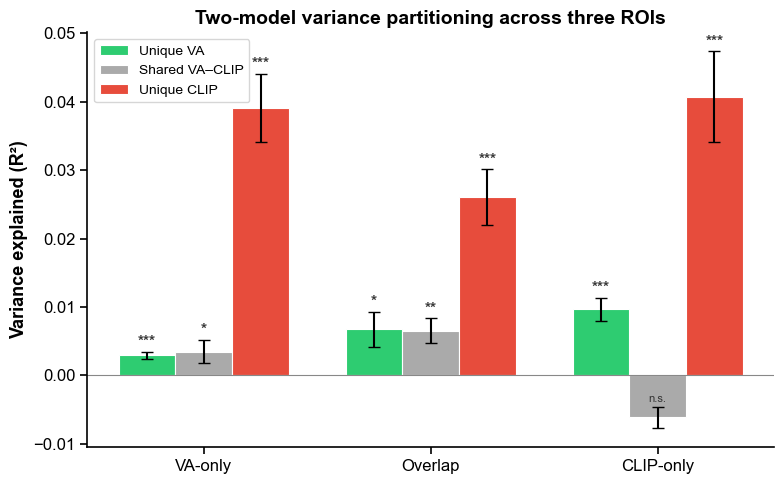


  Summary

VA-only:
             Unique VA: mean R² = 0.0030, t = 6.26, p(FDR) = 0.0000 ***
        Shared VA–CLIP: mean R² = 0.0035, t = 2.06, p(FDR) = 0.0293 *
           Unique CLIP: mean R² = 0.0390, t = 7.80, p(FDR) = 0.0000 ***

Overlap:
             Unique VA: mean R² = 0.0068, t = 2.62, p(FDR) = 0.0100 *
        Shared VA–CLIP: mean R² = 0.0066, t = 3.68, p(FDR) = 0.0011 **
           Unique CLIP: mean R² = 0.0260, t = 6.41, p(FDR) = 0.0000 ***

CLIP-only:
             Unique VA: mean R² = 0.0097, t = 5.68, p(FDR) = 0.0000 ***
        Shared VA–CLIP: mean R² = -0.0061, t = -3.87, p(FDR) = 0.9995 n.s.
           Unique CLIP: mean R² = 0.0408, t = 6.15, p(FDR) = 0.0000 ***


In [46]:
# ---------------------------------------------------------------------------
# 1. Define three ROI masks
# ---------------------------------------------------------------------------
overlap_mask   = va_mask & clip_mask
va_only_mask   = va_mask & ~clip_mask
clip_only_mask = clip_mask & ~va_mask

print(f"VA-only voxels   : {int(va_only_mask.sum())}")
print(f"Overlap voxels   : {int(overlap_mask.sum())}")
print(f"CLIP-only voxels : {int(clip_only_mask.sum())}")

# ---------------------------------------------------------------------------
# 2. Compute fMRI RDMs for each ROI
# ---------------------------------------------------------------------------
overlap_rdms   = compute_rdm_in_mask(brain_data, overlap_mask)
va_only_rdms   = compute_rdm_in_mask(brain_data, va_only_mask)
clip_only_rdms = compute_rdm_in_mask(brain_data, clip_only_mask)

# ---------------------------------------------------------------------------
# 3. Two-model variance partitioning (VA and CLIP only)
# ---------------------------------------------------------------------------
model_rdms_2 = {'VA': va_rdm, 'CLIP': clip_rdm}

def _r2(X, y):
    if X.ndim == 1: X = X.reshape(-1, 1)
    X = np.nan_to_num(zscore(X, axis=0, ddof=1))
    yz = zscore(y, ddof=1)
    m = LinearRegression().fit(X, yz)
    return m.score(X, yz)

def variance_partition_2model(y, predictors):
    """Two-predictor variance partitioning: 3 components (unique_A, unique_B, shared)."""
    assert len(predictors) == 2
    (n1, x1), (n2, x2) = list(predictors.items())

    r1   = _r2(x1, y)
    r2   = _r2(x2, y)
    rall = _r2(np.column_stack([x1, x2]), y)

    u1 = rall - r2          # unique to model 1
    u2 = rall - r1          # unique to model 2
    shared = r1 + r2 - rall # shared by both

    return {
        'R2_full': rall,
        f'R2_{n1}': r1,
        f'R2_{n2}': r2,
        f'unique_{n1}': u1,
        f'unique_{n2}': u2,
        f'shared_{n1}_{n2}': shared,
    }

def variance_partition_2model_per_subject(fmri_rdms, model_rdms):
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    rows = []
    for s in range(fmri_rdms.shape[0]):
        yv = upper_tri(fmri_rdms[s])
        row = variance_partition_2model(yv, mv)
        row['subject'] = s
        rows.append(row)
    return pd.DataFrame(rows).set_index('subject')

# ---------------------------------------------------------------------------
# 4. Run on all three ROIs
# ---------------------------------------------------------------------------
vp_results = {}
for roi_name, roi_rdms in [('VA-only',   va_only_rdms),
                            ('Overlap',   overlap_rdms),
                            ('CLIP-only', clip_only_rdms)]:
    df = variance_partition_2model_per_subject(roi_rdms, model_rdms_2)
    vp_results[roi_name] = df
    print(f"\n{'='*50}")
    print(f"  {roi_name}")
    print(f"{'='*50}")
    print(df[['unique_VA', 'unique_CLIP', 'shared_VA_CLIP']].describe().loc[['mean', 'std']].round(4))

# ---------------------------------------------------------------------------
# 5. Group stats with FDR correction
# ---------------------------------------------------------------------------
all_stats = []
for roi_name, df in vp_results.items():
    for col in ['unique_VA', 'unique_CLIP', 'shared_VA_CLIP', 'R2_full']:
        vals = df[col].values
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        all_stats.append({
            'ROI': roi_name, 'component': col,
            'mean': vals.mean(),
            'sem': vals.std(ddof=1) / np.sqrt(len(vals)),
            't': t, 'p_uncorr': p,
        })

stats_df = pd.DataFrame(all_stats)
rejected, p_fdr = fdrcorrection(stats_df['p_uncorr'].values, alpha=0.05)
stats_df['p_fdr'] = p_fdr
stats_df['sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.' for p in p_fdr]

print("\n" + "="*80)
print("  Group statistics (FDR-corrected across all ROIs and components)")
print("="*80)
print(stats_df.to_string(index=False))
stats_df.to_csv(os.path.join(OUT_DIR, 'variance_partition_3roi_stats.csv'), index=False)

# ---------------------------------------------------------------------------
# 6. Plot: grouped bar chart
# ---------------------------------------------------------------------------
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

roi_order = ['VA-only', 'Overlap', 'CLIP-only']
components_plot = ['unique_VA', 'shared_VA_CLIP', 'unique_CLIP']
comp_colors = {'unique_VA': '#2ecc71', 'shared_VA_CLIP': '#AAAAAA', 'unique_CLIP': '#e74c3c'}
comp_labels = {'unique_VA': 'Unique VA', 'shared_VA_CLIP': 'Shared VA–CLIP', 'unique_CLIP': 'Unique CLIP'}

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(roi_order))
n_comp = len(components_plot)
width = 0.25

for i, comp in enumerate(components_plot):
    means = [vp_results[roi][comp].mean() for roi in roi_order]
    sems  = [vp_results[roi][comp].sem()  for roi in roi_order]

    bars = ax.bar(x + i * width - width, means, width,
                  yerr=sems, capsize=4,
                  color=comp_colors[comp], edgecolor='white', linewidth=0.8,
                  label=comp_labels[comp])

    # Significance stars
    for j, roi in enumerate(roi_order):
        row = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == comp)]
        if not row.empty:
            sig = row['sig'].values[0]
            y_pos = means[j] + sems[j] + 0.0004
            fontweight = 'bold' if sig != 'n.s.' else 'normal'
            fontsize = 11 if sig != 'n.s.' else 8
            ax.text(x[j] + i * width - width, y_pos, sig,
                    ha='center', va='bottom', fontsize=fontsize,
                    fontweight=fontweight, color='#333333')

ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(roi_order, fontsize=12)
ax.set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, framealpha=0.8)
ax.set_title('Two-model variance partitioning across three ROIs', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_3roi.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_3roi.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("  Summary")
print("="*80)
for roi in roi_order:
    print(f"\n{roi}:")
    for comp in components_plot:
        row = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == comp)]
        print(f"  {comp_labels[comp]:>20s}: mean R² = {row['mean'].values[0]:.4f}, "
              f"t = {row['t'].values[0]:.2f}, p(FDR) = {row['p_fdr'].values[0]:.4f} {row['sig'].values[0]}")

VA-only voxels   : 554
Overlap voxels   : 484
CLIP-only voxels : 1543

  VA-only
      unique_VA  unique_CLIP  unique_GIST  shared_VA_CLIP_only  \
mean     0.0029       0.0368       0.0060               0.0037   
std      0.0022       0.0226       0.0084               0.0075   

      shared_VA_GIST_only  shared_CLIP_GIST_only  shared_all  
mean               0.0001                 0.0022     -0.0002  
std                0.0005                 0.0026      0.0004  

  Overlap
      unique_VA  unique_CLIP  unique_GIST  shared_VA_CLIP_only  \
mean     0.0068       0.0239       0.0087               0.0068   
std      0.0110       0.0179       0.0097               0.0081   

      shared_VA_GIST_only  shared_CLIP_GIST_only  shared_all  
mean              -0.0000                 0.0021     -0.0002  
std                0.0008                 0.0027      0.0004  

  CLIP-only
      unique_VA  unique_CLIP  unique_GIST  shared_VA_CLIP_only  \
mean     0.0093       0.0390       0.0042            

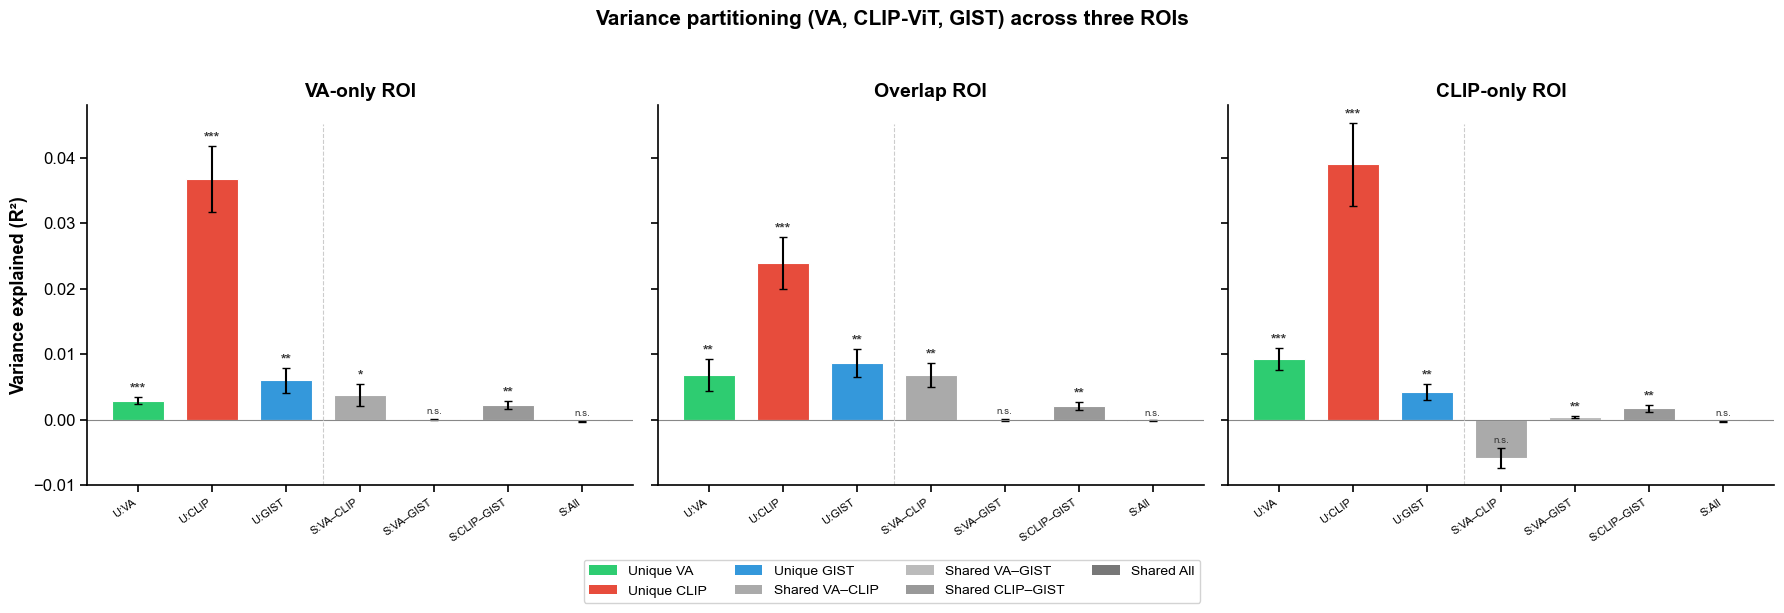


  Summary

VA-only:
             Unique VA: mean R² = 0.0029, t = 5.83, p(FDR) = 0.0000 ***
           Unique CLIP: mean R² = 0.0368, t = 7.29, p(FDR) = 0.0000 ***
           Unique GIST: mean R² = 0.0060, t = 3.17, p(FDR) = 0.0043 **
        Shared VA–CLIP: mean R² = 0.0037, t = 2.21, p(FDR) = 0.0262 *
        Shared VA–GIST: mean R² = 0.0001, t = 0.55, p(FDR) = 0.3725 n.s.
      Shared CLIP–GIST: mean R² = 0.0022, t = 3.80, p(FDR) = 0.0014 **
            Shared All: mean R² = -0.0002, t = -2.60, p(FDR) = 0.9993 n.s.

Overlap:
             Unique VA: mean R² = 0.0068, t = 2.75, p(FDR) = 0.0089 **
           Unique CLIP: mean R² = 0.0239, t = 5.97, p(FDR) = 0.0000 ***
           Unique GIST: mean R² = 0.0087, t = 4.00, p(FDR) = 0.0010 **
        Shared VA–CLIP: mean R² = 0.0068, t = 3.75, p(FDR) = 0.0015 **
        Shared VA–GIST: mean R² = -0.0000, t = -0.10, p(FDR) = 0.6470 n.s.
      Shared CLIP–GIST: mean R² = 0.0021, t = 3.45, p(FDR) = 0.0025 **
            Shared All: mean R² = 

In [47]:
# ---------------------------------------------------------------------------
# 1. Define three ROI masks
# ---------------------------------------------------------------------------
overlap_mask   = va_mask & clip_mask
va_only_mask   = va_mask & ~clip_mask
clip_only_mask = clip_mask & ~va_mask

print(f"VA-only voxels   : {int(va_only_mask.sum())}")
print(f"Overlap voxels   : {int(overlap_mask.sum())}")
print(f"CLIP-only voxels : {int(clip_only_mask.sum())}")

# ---------------------------------------------------------------------------
# 2. Compute fMRI RDMs for each ROI
# ---------------------------------------------------------------------------
overlap_rdms   = compute_rdm_in_mask(brain_data, overlap_mask)
va_only_rdms   = compute_rdm_in_mask(brain_data, va_only_mask)
clip_only_rdms = compute_rdm_in_mask(brain_data, clip_only_mask)

# ---------------------------------------------------------------------------
# 3. Three-model variance partitioning (VA, CLIP, GIST)
# ---------------------------------------------------------------------------
model_rdms_3 = {'VA': va_rdm, 'CLIP': clip_rdm, 'GIST': gist_rdm}

def _r2(X, y):
    if X.ndim == 1: X = X.reshape(-1, 1)
    X = np.nan_to_num(zscore(X, axis=0, ddof=1))
    yz = zscore(y, ddof=1)
    m = LinearRegression().fit(X, yz)
    return m.score(X, yz)

def variance_partition(y, predictors):
    assert len(predictors) == 3
    (n1, x1), (n2, x2), (n3, x3) = list(predictors.items())

    r1 = _r2(x1, y); r2 = _r2(x2, y); r3 = _r2(x3, y)
    r12 = _r2(np.column_stack([x1, x2]), y)
    r13 = _r2(np.column_stack([x1, x3]), y)
    r23 = _r2(np.column_stack([x2, x3]), y)
    rall = _r2(np.column_stack([x1, x2, x3]), y)

    u1 = rall - r23
    u2 = rall - r13
    u3 = rall - r12
    c12 = r1 + r2 - r12
    c13 = r1 + r3 - r13
    c23 = r2 + r3 - r23
    c123 = r1 + r2 + r3 - r12 - r13 - r23 + rall
    s12_only = c12 - c123
    s13_only = c13 - c123
    s23_only = c23 - c123

    return {
        'R2_full': rall,
        f'unique_{n1}': u1, f'unique_{n2}': u2, f'unique_{n3}': u3,
        f'shared_{n1}_{n2}_only': s12_only,
        f'shared_{n1}_{n3}_only': s13_only,
        f'shared_{n2}_{n3}_only': s23_only,
        'shared_all': c123,
    }

def variance_partition_per_subject(fmri_rdms, model_rdms):
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    rows = []
    for s in range(fmri_rdms.shape[0]):
        yv = upper_tri(fmri_rdms[s])
        row = variance_partition(yv, mv)
        row['subject'] = s
        rows.append(row)
    return pd.DataFrame(rows).set_index('subject')

# ---------------------------------------------------------------------------
# 4. Run on all three ROIs
# ---------------------------------------------------------------------------
vp_results = {}
for roi_name, roi_rdms in [('VA-only',   va_only_rdms),
                            ('Overlap',   overlap_rdms),
                            ('CLIP-only', clip_only_rdms)]:
    df = variance_partition_per_subject(roi_rdms, model_rdms_3)
    vp_results[roi_name] = df
    print(f"\n{'='*50}")
    print(f"  {roi_name}")
    print(f"{'='*50}")
    print(df[['unique_VA', 'unique_CLIP', 'unique_GIST',
              'shared_VA_CLIP_only', 'shared_VA_GIST_only',
              'shared_CLIP_GIST_only', 'shared_all']].describe().loc[['mean', 'std']].round(4))

# ---------------------------------------------------------------------------
# 5. Group stats with FDR correction across ALL ROIs and components
# ---------------------------------------------------------------------------
components_all = ['unique_VA', 'unique_CLIP', 'unique_GIST',
                  'shared_VA_CLIP_only', 'shared_VA_GIST_only',
                  'shared_CLIP_GIST_only', 'shared_all', 'R2_full']

all_stats = []
for roi_name, df in vp_results.items():
    for col in components_all:
        vals = df[col].values
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        all_stats.append({
            'ROI': roi_name, 'component': col,
            'mean': vals.mean(),
            'sem': vals.std(ddof=1) / np.sqrt(len(vals)),
            't': t, 'p_uncorr': p,
        })

stats_df = pd.DataFrame(all_stats)
rejected, p_fdr = fdrcorrection(stats_df['p_uncorr'].values, alpha=0.05)
stats_df['p_fdr'] = p_fdr
stats_df['sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.' for p in p_fdr]

print("\n" + "="*80)
print("  Group statistics (FDR-corrected across all ROIs and components)")
print("="*80)
print(stats_df.to_string(index=False))
stats_df.to_csv(os.path.join(OUT_DIR, 'variance_partition_3roi_3model_stats.csv'), index=False)

# ---------------------------------------------------------------------------
# 6. Plot: grouped bar chart — 7 components × 3 ROIs
# ---------------------------------------------------------------------------
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

roi_order = ['VA-only', 'Overlap', 'CLIP-only']
components_plot = ['unique_VA', 'unique_CLIP', 'unique_GIST',
                   'shared_VA_CLIP_only', 'shared_VA_GIST_only',
                   'shared_CLIP_GIST_only', 'shared_all']
comp_colors = {
    'unique_VA':              '#2ecc71',
    'unique_CLIP':            '#e74c3c',
    'unique_GIST':            '#3498db',
    'shared_VA_CLIP_only':    '#AAAAAA',
    'shared_VA_GIST_only':    '#BBBBBB',
    'shared_CLIP_GIST_only':  '#999999',
    'shared_all':             '#777777',
}
comp_labels = {
    'unique_VA':              'Unique VA',
    'unique_CLIP':            'Unique CLIP',
    'unique_GIST':            'Unique GIST',
    'shared_VA_CLIP_only':    'Shared VA–CLIP',
    'shared_VA_GIST_only':    'Shared VA–GIST',
    'shared_CLIP_GIST_only':  'Shared CLIP–GIST',
    'shared_all':             'Shared All',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax_idx, roi in enumerate(roi_order):
    ax = axes[ax_idx]
    df = vp_results[roi]
    x = np.arange(len(components_plot))

    means = [df[c].mean() for c in components_plot]
    sems  = [df[c].sem()  for c in components_plot]
    colors = [comp_colors[c] for c in components_plot]

    bars = ax.bar(x, means, yerr=sems, capsize=3,
                  color=colors, edgecolor='white', linewidth=0.8, width=0.7)

    # Significance stars
    for i, comp in enumerate(components_plot):
        row = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == comp)]
        if not row.empty:
            sig = row['sig'].values[0]
            y_pos = means[i] + sems[i] + 0.0004
            fontweight = 'bold' if sig != 'n.s.' else 'normal'
            fontsize = 10 if sig != 'n.s.' else 7
            ax.text(i, y_pos, sig, ha='center', va='bottom',
                    fontsize=fontsize, fontweight=fontweight, color='#333333')

    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([comp_labels[c].replace('Shared ', 'S:').replace('Unique ', 'U:')
                        for c in components_plot],
                       fontsize=8, rotation=35, ha='right')
    ax.set_title(f'{roi} ROI', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Separator between unique and shared
    ax.axvline(2.5, color='#CCCCCC', linewidth=0.8, linestyle='--', ymin=0, ymax=0.95)

axes[0].set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')

# Shared legend below all subplots
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=comp_colors[c], label=comp_labels[c]) for c in components_plot]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.85, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Variance partitioning (VA, CLIP-ViT, GIST) across three ROIs',
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_3roi_3model.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_3roi_3model.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("  Summary")
print("="*80)
for roi in roi_order:
    print(f"\n{roi}:")
    for comp in components_plot:
        row = stats_df[(stats_df['ROI'] == roi) & (stats_df['component'] == comp)]
        print(f"  {comp_labels[comp]:>20s}: mean R² = {row['mean'].values[0]:.4f}, "
              f"t = {row['t'].values[0]:.2f}, p(FDR) = {row['p_fdr'].values[0]:.4f} {row['sig'].values[0]}")

In [48]:
print(f"VA-only voxels   : {int(va_only_mask.sum())}")
print(f"Overlap voxels   : {int(overlap_mask.sum())}")
print(f"CLIP-only voxels : {int(clip_only_mask.sum())}")

VA-only voxels   : 554
Overlap voxels   : 484
CLIP-only voxels : 1543


In [50]:
voxel_counts = {'VA-only': int(va_only_mask.sum()),
                'Overlap': int(overlap_mask.sum()),
                'CLIP-only': int(clip_only_mask.sum())}

for roi_name, df in vp_results.items():
    r2_full = df['R2_full'].mean()
    u_va = df['unique_VA'].mean()
    u_clip = df['unique_CLIP'].mean()
    u_gist = df['unique_GIST'].mean()
    s_vc = df['shared_VA_CLIP_only'].mean()
    print(f"\n{roi_name} ({voxel_counts[roi_name]} voxels):")
    print(f"  R2_full          = {r2_full:.4f}")
    print(f"  unique_VA        = {u_va:.4f}  ({u_va/r2_full*100:.1f}%)")
    print(f"  unique_CLIP      = {u_clip:.4f}  ({u_clip/r2_full*100:.1f}%)")
    print(f"  unique_GIST      = {u_gist:.4f}  ({u_gist/r2_full*100:.1f}%)")
    print(f"  shared_VA_CLIP   = {s_vc:.4f}  ({s_vc/r2_full*100:.1f}%)")


VA-only (554 voxels):
  R2_full          = 0.0515
  unique_VA        = 0.0029  (5.6%)
  unique_CLIP      = 0.0368  (71.6%)
  unique_GIST      = 0.0060  (11.6%)
  shared_VA_CLIP   = 0.0037  (7.2%)

Overlap (484 voxels):
  R2_full          = 0.0481
  unique_VA        = 0.0068  (14.1%)
  unique_CLIP      = 0.0239  (49.8%)
  unique_GIST      = 0.0087  (18.1%)
  shared_VA_CLIP   = 0.0068  (14.1%)

CLIP-only (1543 voxels):
  R2_full          = 0.0485
  unique_VA        = 0.0093  (19.1%)
  unique_CLIP      = 0.0390  (80.6%)
  unique_GIST      = 0.0042  (8.7%)
  shared_VA_CLIP   = -0.0059  (-12.1%)


In [53]:
from nilearn.image import new_img_like

# Save VA-only mask as NIfTI
va_only_img = new_img_like(va_mask_img, va_only_mask.astype(np.int16))
va_only_path = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\final_results\va_only_mask.nii.gz"
va_only_img.to_filename(va_only_path)
print(f"Saved: {va_only_path}")
print(f"Voxels: {int(va_only_mask.sum())}")

Saved: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\final_results\va_only_mask.nii.gz
Voxels: 554


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_62088\547600204.py:7: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  va_only_ant_resampled = resample_to_img(va_only_ant_raw, va_mask_img, interpolation='nearest')
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_62088\547600204.py:7: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  va_only_ant_resampled = resample_to_img(va_only_ant_raw, va_mask_img, interpolation='nearest')


Original shape : (207, 256, 215)
Resampled shape: (53, 63, 46)
Brain data shape per subject: (53, 63, 46)
VA-only anterior voxels: 106
RDMs shape: (20, 60, 60)

  VA-only Anterior ROI
            component      mean      sem         t  p_one_sided    p_fdr  sig
              R2_full  0.023917 0.004416  5.415680     0.000016 0.000127  ***
            unique_VA  0.003550 0.001307  2.716238     0.006850 0.013700    *
          unique_CLIP  0.013421 0.004092  3.279395     0.001972 0.005259   **
          unique_GIST  0.004352 0.001208  3.602203     0.000949 0.003798   **
  shared_VA_CLIP_only  0.002500 0.001099  2.275839     0.017311 0.027698    *
  shared_VA_GIST_only -0.000017 0.000053 -0.321126     0.624190 0.698286 n.s.
shared_CLIP_GIST_only  0.000133 0.000278  0.479564     0.318506 0.424674 n.s.
           shared_all -0.000022 0.000042 -0.528269     0.698286 0.698286 n.s.

R2_full = 0.0239
  unique_VA                 = 0.0035  (14.8%)
  unique_CLIP               = 0.0134  (56.1%)
  un

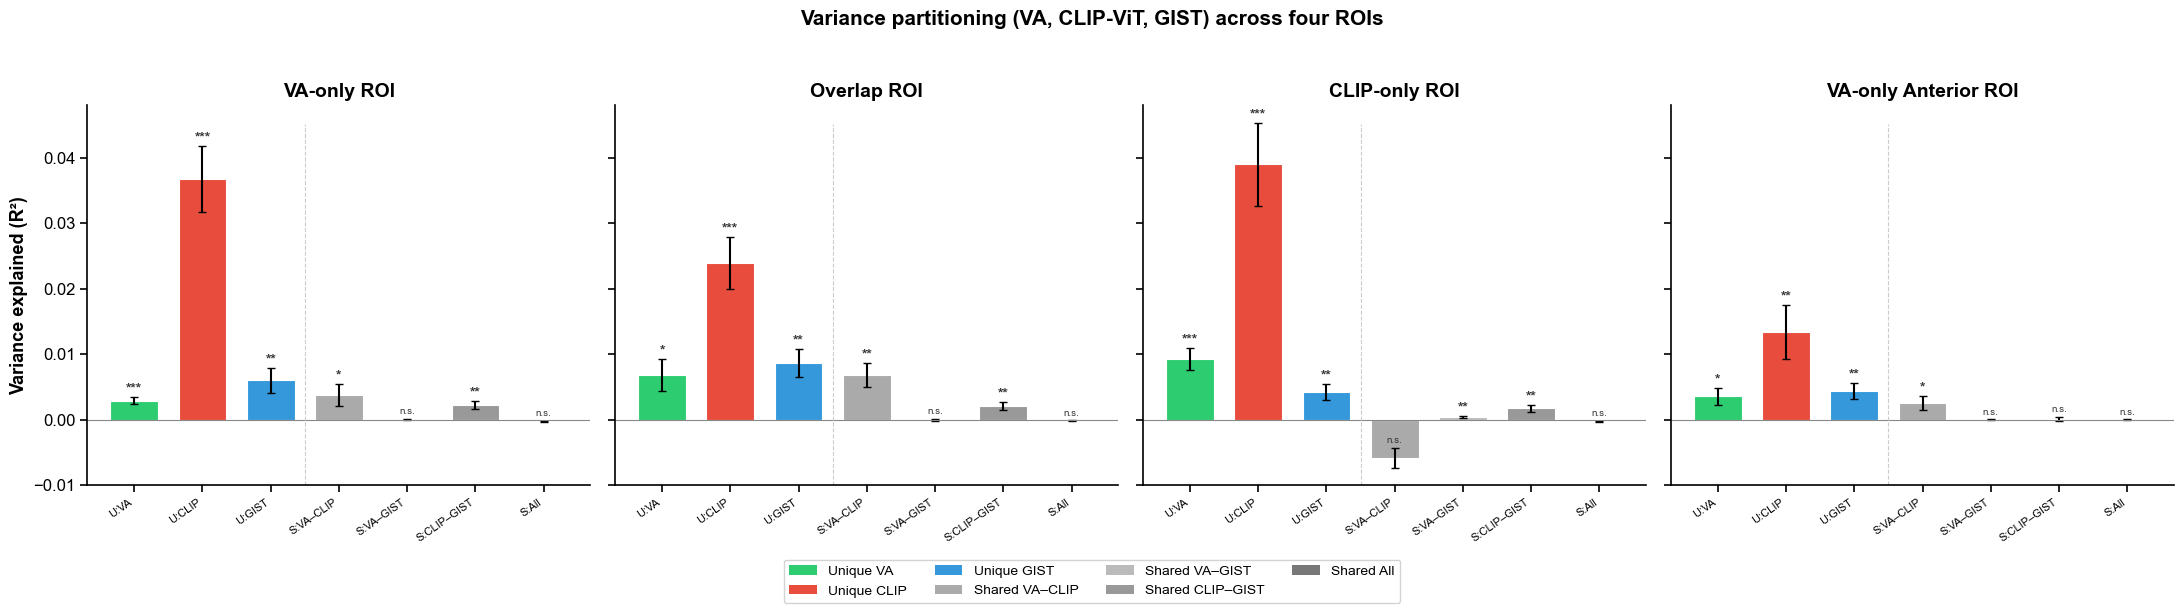


VA-only (554 voxels):
  R2_full = 0.0515
  unique_VA                 = 0.0029  (5.6%)
  unique_CLIP               = 0.0368  (71.6%)
  unique_GIST               = 0.0060  (11.6%)
  shared_VA_CLIP_only       = 0.0037  (7.2%)

Overlap (484 voxels):
  R2_full = 0.0481
  unique_VA                 = 0.0068  (14.1%)
  unique_CLIP               = 0.0239  (49.8%)
  unique_GIST               = 0.0087  (18.1%)
  shared_VA_CLIP_only       = 0.0068  (14.1%)

CLIP-only (1543 voxels):
  R2_full = 0.0485
  unique_VA                 = 0.0093  (19.1%)
  unique_CLIP               = 0.0390  (80.6%)
  unique_GIST               = 0.0042  (8.7%)
  shared_VA_CLIP_only       = -0.0059  (-12.1%)

VA-only Anterior (106 voxels):
  R2_full = 0.0239
  unique_VA                 = 0.0035  (14.8%)
  unique_CLIP               = 0.0134  (56.1%)
  unique_GIST               = 0.0044  (18.2%)
  shared_VA_CLIP_only       = 0.0025  (10.5%)


In [60]:

from nilearn.image import resample_to_img

# Load the anterior VA-only mask
va_only_ant_raw = nib.load(r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\final_results\va_only_mask_ant2.nii.gz")

# Resample to match the VA mask (which matches brain_data)
va_only_ant_resampled = resample_to_img(va_only_ant_raw, va_mask_img, interpolation='nearest')
va_only_ant_mask = va_only_ant_resampled.get_fdata() > 0

print(f"Original shape : {va_only_ant_raw.shape}")
print(f"Resampled shape: {va_only_ant_mask.shape}")
print(f"Brain data shape per subject: {brain_data.shape[2:]}")
print(f"VA-only anterior voxels: {int(va_only_ant_mask.sum())}")

# Now compute RDMs — shapes should match
va_only_ant_rdms = compute_rdm_in_mask(brain_data, va_only_ant_mask)
print(f"RDMs shape: {va_only_ant_rdms.shape}")

# Run variance partitioning
df_vp_ant = variance_partition_per_subject(va_only_ant_rdms, model_rdms_3)

# Group stats
vp_cols = [c for c in df_vp_ant.columns if c.startswith(('unique_', 'shared_', 'R2_full'))]
stats_ant = group_stats(df_vp_ant, vp_cols)
rejected, p_fdr = fdrcorrection(stats_ant['p_one_sided'].values, alpha=0.05)
stats_ant['p_fdr'] = p_fdr
stats_ant['sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.' for p in p_fdr]

print("\n" + "="*60)
print("  VA-only Anterior ROI")
print("="*60)
print(stats_ant.to_string(index=False))

# Proportions
r2_full = df_vp_ant['R2_full'].mean()
print(f"\nR2_full = {r2_full:.4f}")
for c in ['unique_VA', 'unique_CLIP', 'unique_GIST', 'shared_VA_CLIP_only']:
    val = df_vp_ant[c].mean()
    print(f"  {c:<25s} = {val:.4f}  ({val/r2_full*100:.1f}%)")

# Plot VA-only Anterior alongside the other three ROIs
roi_order_4 = ['VA-only', 'Overlap', 'CLIP-only', 'VA-only Anterior']
vp_results['VA-only Anterior'] = df_vp_ant

components_plot = ['unique_VA', 'unique_CLIP', 'unique_GIST',
                   'shared_VA_CLIP_only', 'shared_VA_GIST_only',
                   'shared_CLIP_GIST_only', 'shared_all']
comp_colors = {
    'unique_VA':              '#2ecc71',
    'unique_CLIP':            '#e74c3c',
    'unique_GIST':            '#3498db',
    'shared_VA_CLIP_only':    '#AAAAAA',
    'shared_VA_GIST_only':    '#BBBBBB',
    'shared_CLIP_GIST_only':  '#999999',
    'shared_all':             '#777777',
}
comp_labels = {
    'unique_VA':              'Unique VA',
    'unique_CLIP':            'Unique CLIP',
    'unique_GIST':            'Unique GIST',
    'shared_VA_CLIP_only':    'Shared VA–CLIP',
    'shared_VA_GIST_only':    'Shared VA–GIST',
    'shared_CLIP_GIST_only':  'Shared CLIP–GIST',
    'shared_all':             'Shared All',
}

# Recompute stats including the new ROI
all_stats_4 = []
for roi_name in roi_order_4:
    df = vp_results[roi_name]
    for col in components_plot + ['R2_full']:
        vals = df[col].values
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        all_stats_4.append({
            'ROI': roi_name, 'component': col,
            'mean': vals.mean(),
            'sem': vals.std(ddof=1) / np.sqrt(len(vals)),
            't': t, 'p_uncorr': p,
        })

stats_df_4 = pd.DataFrame(all_stats_4)
rejected, p_fdr = fdrcorrection(stats_df_4['p_uncorr'].values, alpha=0.05)
stats_df_4['p_fdr'] = p_fdr
stats_df_4['sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.' for p in p_fdr]

# Plot
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)

for ax_idx, roi in enumerate(roi_order_4):
    ax = axes[ax_idx]
    df = vp_results[roi]
    x = np.arange(len(components_plot))

    means = [df[c].mean() for c in components_plot]
    sems  = [df[c].sem()  for c in components_plot]
    colors = [comp_colors[c] for c in components_plot]

    bars = ax.bar(x, means, yerr=sems, capsize=3,
                  color=colors, edgecolor='white', linewidth=0.8, width=0.7)

    for i, comp in enumerate(components_plot):
        row = stats_df_4[(stats_df_4['ROI'] == roi) & (stats_df_4['component'] == comp)]
        if not row.empty:
            sig = row['sig'].values[0]
            y_pos = means[i] + sems[i] + 0.0004
            fontweight = 'bold' if sig != 'n.s.' else 'normal'
            fontsize = 10 if sig != 'n.s.' else 7
            ax.text(i, y_pos, sig, ha='center', va='bottom',
                    fontsize=fontsize, fontweight=fontweight, color='#333333')

    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([comp_labels[c].replace('Shared ', 'S:').replace('Unique ', 'U:')
                        for c in components_plot],
                       fontsize=8, rotation=35, ha='right')
    ax.set_title(f'{roi} ROI', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(2.5, color='#CCCCCC', linewidth=0.8, linestyle='--', ymin=0, ymax=0.95)

axes[0].set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=comp_colors[c], label=comp_labels[c]) for c in components_plot]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.85, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Variance partitioning (VA, CLIP-ViT, GIST) across four ROIs',
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_4roi_3model.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'variance_partition_4roi_3model.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print proportions for all four ROIs
voxel_counts = {'VA-only': int(va_only_mask.sum()),
                'Overlap': int(overlap_mask.sum()),
                'CLIP-only': int(clip_only_mask.sum()),
                'VA-only Anterior': int(va_only_ant_mask.sum())}

for roi_name in roi_order_4:
    df = vp_results[roi_name]
    r2_full = df['R2_full'].mean()
    print(f"\n{roi_name} ({voxel_counts[roi_name]} voxels):")
    print(f"  R2_full = {r2_full:.4f}")
    for c in ['unique_VA', 'unique_CLIP', 'unique_GIST', 'shared_VA_CLIP_only']:
        val = df[c].mean()
        print(f"  {c:<25s} = {val:.4f}  ({val/r2_full*100:.1f}%)")

## 7. Temporal extension: time-resolved variance partitioning on EEG RDMs

Now apply the same variance partitioning at every EEG time point, so we can see when each model contributes uniquely vs. jointly across the processing cascade.

In [14]:
def compute_eeg_rdms(eeg_arr, metric='correlation'):
    n_subj, n_ch, n_stim, n_tp = eeg_arr.shape
    rdms = np.zeros((n_subj, n_stim, n_stim, n_tp))
    for s in range(n_subj):
        for t in range(n_tp):
            data_t = eeg_arr[s, :, :, t].T
            rdms[s, :, :, t] = pairwise_distances(data_t, metric=metric)
    return rdms

eeg_rdms = compute_eeg_rdms(eeg)
print("EEG RDMs shape:", eeg_rdms.shape)

EEG RDMs shape: (20, 60, 60, 575)


In [15]:
def temporal_variance_partition(eeg_rdms, model_rdms):
    mv = {k: upper_tri(v) for k, v in model_rdms.items()}
    n_subj, N, _, n_tp = eeg_rdms.shape
    dummy = variance_partition(np.random.randn(len(list(mv.values())[0])), mv)
    comp_names = list(dummy.keys())
    out = np.zeros((n_subj, n_tp, len(comp_names)))
    for s in tqdm(range(n_subj), desc="Subjects"):
        for t in range(n_tp):
            yv = upper_tri(np.nan_to_num(eeg_rdms[s, :, :, t]))
            row = variance_partition(yv, mv)
            out[s, t, :] = [row[c] for c in comp_names]
    return out, comp_names

temporal_vp, comp_names = temporal_variance_partition(eeg_rdms, model_rdms)
np.save(os.path.join(OUT_DIR, 'temporal_variance_partition.npy'), temporal_vp)
print("Components tracked:", comp_names)

Subjects: 100%|██████████| 20/20 [00:58<00:00,  2.95s/it]

Components tracked: ['R2_full', 'unique_VA', 'unique_CLIP', 'unique_GIST', 'shared_VA_CLIP_only', 'shared_VA_GIST_only', 'shared_CLIP_GIST_only', 'shared_all']


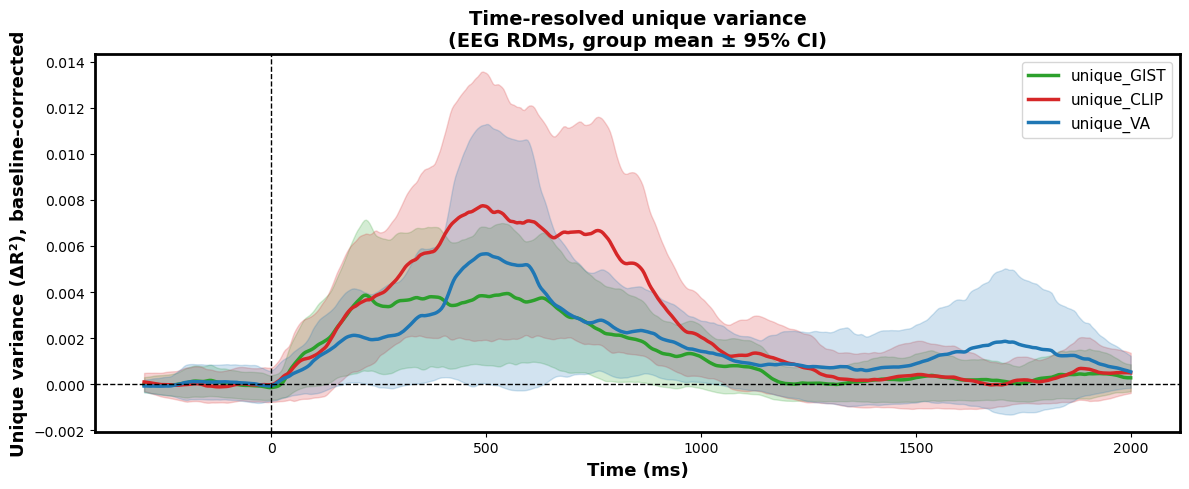

In [16]:
# Plot time-resolved unique variance for each model (with 95% CI across subjects)
x_ms = np.arange(1, 576) * 4 - 300
baseline_index = np.where(x_ms >= 0)[0][0]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(2)

colors = {'unique_VA': 'tab:blue', 'unique_CLIP': 'tab:red', 'unique_GIST': 'tab:green'}
for comp in ['unique_GIST', 'unique_CLIP', 'unique_VA']:
    idx = comp_names.index(comp)
    series = temporal_vp[:, :, idx]   # (subj, tp)
    baseline = series[:, :baseline_index].mean(axis=1, keepdims=True)
    series_bc = series - baseline
    mean = smooth(series_bc.mean(axis=0))
    sem  = smooth(series_bc.std(axis=0, ddof=1) / np.sqrt(series_bc.shape[0]))
    ax.plot(x_ms, mean, label=comp, color=colors[comp], linewidth=2.5)
    ax.fill_between(x_ms, mean - 1.96*sem, mean + 1.96*sem, alpha=0.2, color=colors[comp])

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Time (ms)", fontsize=13, fontweight='bold')
ax.set_ylabel("Unique variance (ΔR²), baseline-corrected", fontsize=13, fontweight='bold')
ax.set_title("Time-resolved unique variance\n(EEG RDMs, group mean ± 95% CI)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'temporal_unique_variance.png'), dpi=150)
plt.show()

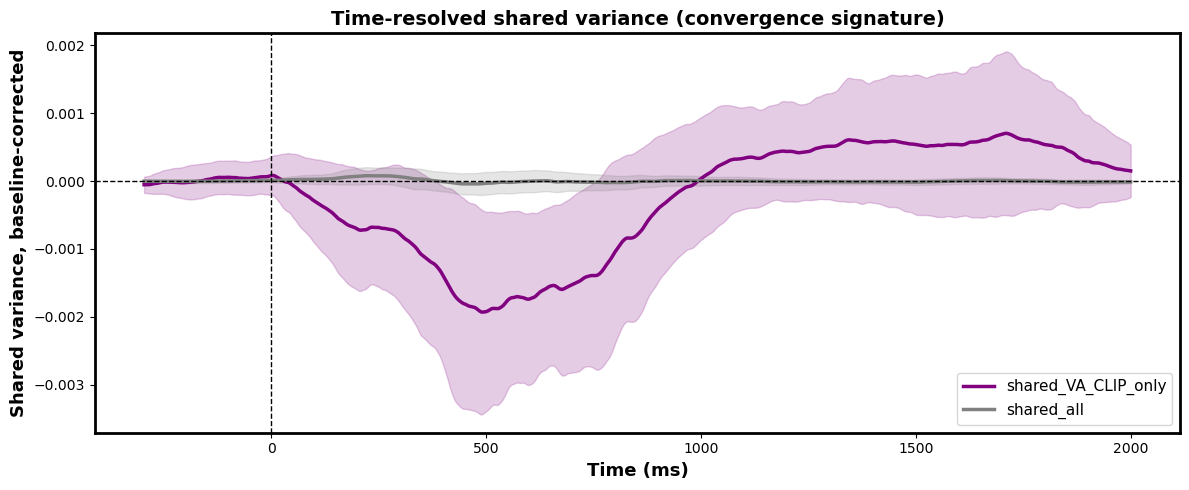

In [17]:
# Also plot the shared components over time -- shows when models converge vs dissociate
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(2)

shared_colors = {'shared_VA_CLIP_only': 'purple', 'shared_all': 'gray'}
for comp in shared_colors:
    if comp not in comp_names:
        continue
    idx = comp_names.index(comp)
    series = temporal_vp[:, :, idx]
    baseline = series[:, :baseline_index].mean(axis=1, keepdims=True)
    series_bc = series - baseline
    mean = smooth(series_bc.mean(axis=0))
    sem  = smooth(series_bc.std(axis=0, ddof=1) / np.sqrt(series_bc.shape[0]))
    ax.plot(x_ms, mean, label=comp, color=shared_colors[comp], linewidth=2.5)
    ax.fill_between(x_ms, mean - 1.96*sem, mean + 1.96*sem, alpha=0.2, color=shared_colors[comp])

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Time (ms)", fontsize=13, fontweight='bold')
ax.set_ylabel("Shared variance, baseline-corrected", fontsize=13, fontweight='bold')
ax.set_title("Time-resolved shared variance (convergence signature)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'temporal_shared_variance.png'), dpi=150)
plt.show()

## 8. What the results mean

**fMRI side (overlap ROI):**
- `unique_VA > 0`: the overlap ROI carries affective structure not explainable by CLIP or GIST. Supports claim that emotion semantics is not fully reducible to scene semantics.
- Large `shared_VA_CLIP_only`: the quantitative convergence-zone signature. Argues scene and emotion semantics **share** representational geometry in this region.
- `unique_GIST` should be small in this ROI (GIST peaks in EVC, not lateral occipito-temporal).

**EEG side (temporal):**
- `unique_GIST` should peak earliest (~100-150 ms) — low-level visual features.
- `unique_CLIP` and `unique_VA` should peak later (~200-700 ms) — semantic/affective processing.
- If `unique_CLIP` peaks before `unique_VA`, that supports the account that scene recognition precedes affective evaluation (consistent with Nummenmaa et al. 2010).
- If `shared_VA_CLIP_only` is sustained across the later window, that's the temporal signature of ongoing convergence between the two semantic streams.